# Linear Equation and Linear Regression

A linear equation describes a straight-line relationship:

$$y = mx + c$$

- `x` is the input (independent variable).
- `y` is the output (dependent variable).
- `m` is the slope: the change in `y` for a one-unit increase in `x`.
- `c` is the intercept: the value of `y` when `x = 0`.

Linear regression learns `m` and `c` from data.

In [1]:
slope = 2
intercept = 3
x_value = 4
y_value = slope * x_value + intercept

print(f'For y = {slope}x + {intercept}, x = {x_value} gives y = {y_value}.')

For y = 2x + 3, x = 4 gives y = 11.


## Sample data and visualization

The points are close to `y = 2x + 3`, with small variation like real measurements. A scatter plot lets us inspect the relationship.

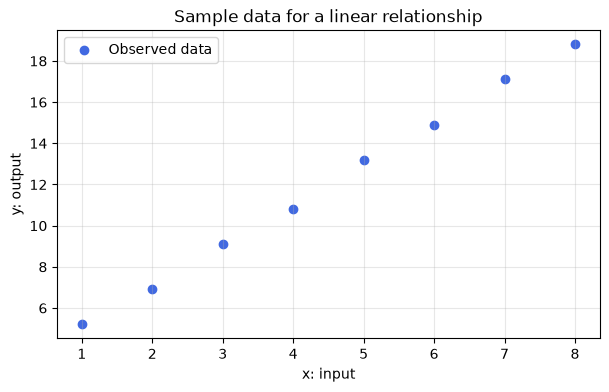

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([5.2, 6.9, 9.1, 10.8, 13.2, 14.9, 17.1, 18.8], dtype=float)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, color='royalblue', label='Observed data')
plt.xlabel('x: input')
plt.ylabel('y: output')
plt.title('Sample data for a linear relationship')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Residuals and mean squared error

A residual is `actual - predicted`. Mean squared error (MSE) averages the squared residuals; smaller MSE means a closer fit.

In [3]:
def linear_equation(x_values, slope, intercept):
    return slope * x_values + intercept

manual_slope = 2.0
manual_intercept = 3.0
manual_predictions = linear_equation(x, manual_slope, manual_intercept)
manual_residuals = y - manual_predictions
manual_mse = np.mean(manual_residuals ** 2)

print('Residuals:', manual_residuals)
print(f'MSE for y = 2x + 3: {manual_mse:.4f}')

Residuals: [ 0.2 -0.1  0.1 -0.2  0.2 -0.1  0.1 -0.2]
MSE for y = 2x + 3: 0.0250


## Least-squares learning and prediction

`np.polyfit(x, y, 1)` fits a degree-one polynomial — a straight line — by least squares. It returns the learned slope and intercept.

Best line: y = 1.9762x + 3.1071
Best-line MSE: 0.0220


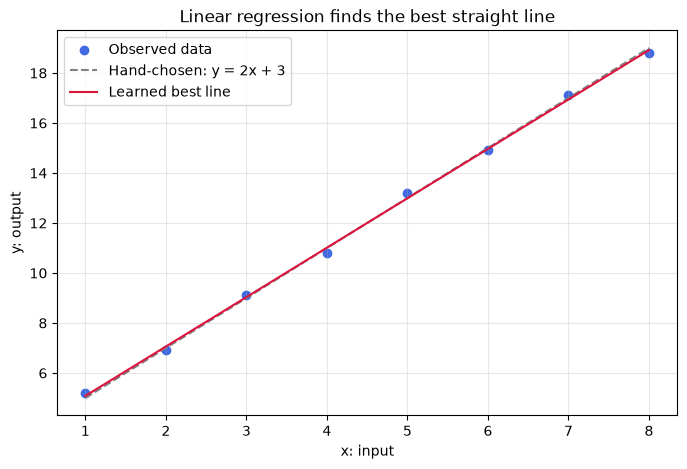

For x = 10, predicted y = 22.87


In [4]:
learned_slope, learned_intercept = np.polyfit(x, y, 1)
best_predictions = linear_equation(x, learned_slope, learned_intercept)
best_mse = np.mean((y - best_predictions) ** 2)

print(f'Best line: y = {learned_slope:.4f}x + {learned_intercept:.4f}')
print(f'Best-line MSE: {best_mse:.4f}')

x_line = np.linspace(x.min(), x.max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='royalblue', label='Observed data')
plt.plot(x_line, linear_equation(x_line, manual_slope, manual_intercept), '--', color='gray', label='Hand-chosen: y = 2x + 3')
plt.plot(x_line, linear_equation(x_line, learned_slope, learned_intercept), color='crimson', label='Learned best line')
plt.xlabel('x: input')
plt.ylabel('y: output')
plt.title('Linear regression finds the best straight line')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

new_x = 10.0
new_y_prediction = linear_equation(new_x, learned_slope, learned_intercept)
print(f'For x = {new_x:.0f}, predicted y = {new_y_prediction:.2f}')

With multiple input features, linear regression generalizes to $y=w_1x_1+w_2x_2+...+w_nx_n+b$. The learned weights $w$ describe feature influence, and $b$ is the intercept.